# 04 — Advance Voting vs Election Day
**Ubon Ratchathani Constituency 10** | Data Science Project 2025/2

Comparing voting patterns between advance voters (5/17) and election day voters (5/18).
Key questions:
1. Do advance voters have different candidate preferences?
2. Do advance voters have different party-list preferences?
3. Are there amphoe-level differences in advance vs election day patterns?

## 0 · Imports & Config

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path

RAW  = Path('../data-final')
OUT  = Path('../data-processed/4')
OUT1  = Path('../data-processed/1')
FIG  = Path('../figures')
FIG.mkdir(parents=True, exist_ok=True)
OUT  = Path('../data-processed/4')

OUT.mkdir(parents=True, exist_ok=True)


df_const  = pd.read_csv(OUT1 / 'constituency_station.csv')
df_party  = pd.read_csv(OUT1 / 'partylist_station.csv')
cand_map  = pd.read_csv(OUT1 / 'candidate_mapping.csv')

color_map = dict(zip(cand_map['party_name'], cand_map['color_hex']))

print('Loaded OK')
print('Station types:', df_const['station_type'].unique())

Loaded OK
Station types: <ArrowStringArray>
['advance_out', 'election_day']
Length: 2, dtype: str


In [3]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# Use a font that supports Thai — try system fonts first
thai_fonts = ['Tahoma', 'Arial Unicode MS', 'Noto Sans Thai', 'TH Sarabun New', 'FreeSans']

available = [f.name for f in fm.fontManager.ttflist]
chosen = next((f for f in thai_fonts if f in available), None)

if chosen:
    plt.rcParams['font.family'] = chosen
    print(f'Using font: {chosen}')
else:
    print('No Thai font found — labels may be garbled')
    print('Available fonts sample:', available[:10])

Using font: Tahoma


## 1 · Split by Station Type

In [4]:
# Constituency
const_adv = df_const[df_const['station_type'] == 'advance_out']
const_ed  = df_const[df_const['station_type'] == 'election_day']

# Party-list
party_adv = df_party[df_party['station_type'] == 'advance_out']
party_ed  = df_party[df_party['station_type'] == 'election_day']

print('=== Constituency ===')
print(f'  advance_out stations : {const_adv["station_name"].nunique()}')
print(f'  election_day stations: {const_ed["station_name"].nunique()}')

print('\n=== Party-list ===')
print(f'  advance_out stations : {party_adv["station_name"].nunique()}')
print(f'  election_day stations: {party_ed["station_name"].nunique()}')

=== Constituency ===
  advance_out stations : 24
  election_day stations: 278

=== Party-list ===
  advance_out stations : 24
  election_day stations: 275


## 2 · Constituency — Advance vs Election Day Vote Share

In [5]:
def vote_share(df, group_cols=['cand_number', 'candidate_name', 'party_name', 'color_hex']):
    agg = df.groupby(group_cols)['score'].sum().reset_index()
    agg['vote_share_%'] = (agg['score'] / agg['score'].sum() * 100).round(2)
    return agg.sort_values('cand_number')

const_adv_share = vote_share(const_adv)
const_ed_share  = vote_share(const_ed)

# Merge
const_compare = const_adv_share[['cand_number', 'candidate_name', 'party_name', 'color_hex', 'vote_share_%']].rename(
    columns={'vote_share_%': 'advance_%'}
).merge(
    const_ed_share[['cand_number', 'vote_share_%']].rename(columns={'vote_share_%': 'election_day_%'}),
    on='cand_number'
)
const_compare['diff_pp'] = (const_compare['advance_%'] - const_compare['election_day_%']).round(2)

print('=== Constituency: Advance vs Election Day ===')
print(const_compare[['candidate_name', 'party_name', 'advance_%', 'election_day_%', 'diff_pp']].to_string(index=False))

=== Constituency: Advance vs Election Day ===
         candidate_name     party_name  advance_%  election_day_%  diff_pp
         นายเกษม ฉิมพลี      ภูมิใจไทย       3.95            4.15    -0.20
   นายสมศักดิ์ บุญประชม เพื่อไทรวมพลัง      61.09           82.59   -21.50
      นายวัชรพล เชื้อคง       เพื่อไทย       7.87            7.46     0.41
นางสาวมิลิณ กำเนิดสิงห์   พลังประชารัฐ       0.87            1.21    -0.34
   นายสิโรตม์ แสนทวีสุข        ประชาชน      25.95            4.24    21.71
           นายยิ่ง ภูผา   ประชาธิปัตย์       0.28            0.35    -0.07


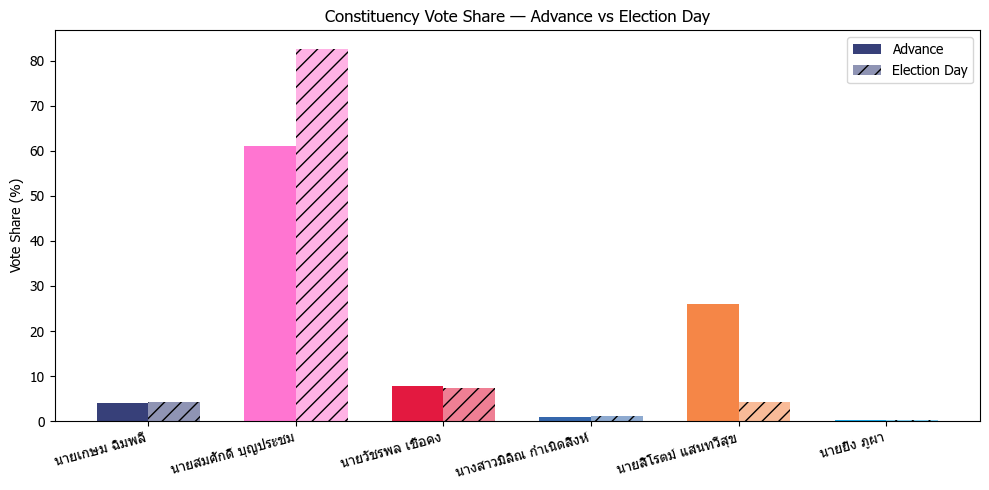

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(len(const_compare))
w = 0.35

ax.bar(x - w/2, const_compare['advance_%'],      width=w,
       color=const_compare['color_hex'].tolist(), label='Advance', alpha=0.9)
ax.bar(x + w/2, const_compare['election_day_%'],  width=w,
       color=const_compare['color_hex'].tolist(), label='Election Day', alpha=0.5, hatch='//')

ax.set_xticks(x)
ax.set_xticklabels(const_compare['candidate_name'], rotation=15, ha='right')
ax.set_ylabel('Vote Share (%)')
ax.set_title('Constituency Vote Share — Advance vs Election Day')
ax.legend()
plt.tight_layout()
plt.savefig(FIG / 'const_advance_vs_ed.png', dpi=150)
plt.show()

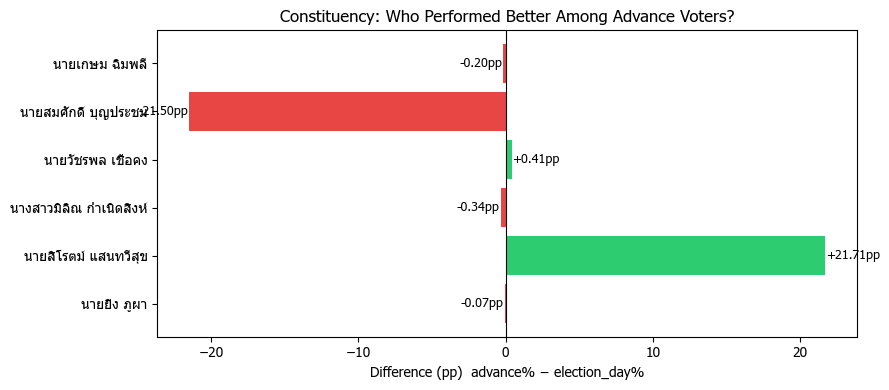

In [7]:
# Diverging bar — diff_pp
fig, ax = plt.subplots(figsize=(9, 4))

colors = ['#e84545' if v < 0 else '#2ecc71' for v in const_compare['diff_pp']]
bars = ax.barh(const_compare['candidate_name'], const_compare['diff_pp'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Difference (pp)  advance% − election_day%')
ax.set_title('Constituency: Who Performed Better Among Advance Voters?')

for bar, val in zip(bars, const_compare['diff_pp']):
    offset = 0.05 if val >= 0 else -0.05
    ha     = 'left' if val >= 0 else 'right'
    ax.text(val + offset, bar.get_y() + bar.get_height() / 2,
            f'{val:+.2f}pp', va='center', ha=ha, fontsize=9)

ax.invert_yaxis()
plt.tight_layout()
plt.savefig(FIG / 'const_advance_diff.png', dpi=150)
plt.show()

## 3 · Party-list — Advance vs Election Day Vote Share (Top 10)

In [8]:
def party_share(df):
    agg = df.groupby(['party_number', 'party_name'])['score'].sum().reset_index()
    agg['vote_share_%'] = (agg['score'] / agg['score'].sum() * 100).round(2)
    return agg.sort_values('vote_share_%', ascending=False)

party_adv_share = party_share(party_adv)
party_ed_share  = party_share(party_ed)

# Top 10 by election day (reference)
top10_nums = party_ed_share.head(10)['party_number'].tolist()

party_compare = (
    party_adv_share[party_adv_share['party_number'].isin(top10_nums)]
    [['party_number', 'party_name', 'vote_share_%']]
    .rename(columns={'vote_share_%': 'advance_%'})
    .merge(
        party_ed_share[party_ed_share['party_number'].isin(top10_nums)]
        [['party_number', 'vote_share_%']]
        .rename(columns={'vote_share_%': 'election_day_%'}),
        on='party_number'
    )
)
party_compare['diff_pp'] = (party_compare['advance_%'] - party_compare['election_day_%']).round(2)
party_compare = party_compare.sort_values('diff_pp')

print('=== Party-list: Advance vs Election Day (Top 10) ===')
print(party_compare[['party_name', 'advance_%', 'election_day_%', 'diff_pp']].to_string(index=False))

=== Party-list: Advance vs Election Day (Top 10) ===
    party_name  advance_%  election_day_%  diff_pp
     ไทรวมพลัง      26.05           39.91   -13.86
พลังไทยรักชาติ       0.01            3.71    -3.70
     ก้าวอิสระ       0.38            2.72    -2.34
เพื่อบ้านเมือง       0.09            2.27    -2.18
   ไทยสร้างไทย       0.18            1.72    -1.54
      ประชาไทย       0.59            1.48    -0.89
       ฟิวชั่น       1.69            1.85    -0.16
  เพื่อชาติไทย       2.22            2.35    -0.13
      เพื่อไทย       8.97            6.81     2.16
       ประชาชน      27.60            5.20    22.40


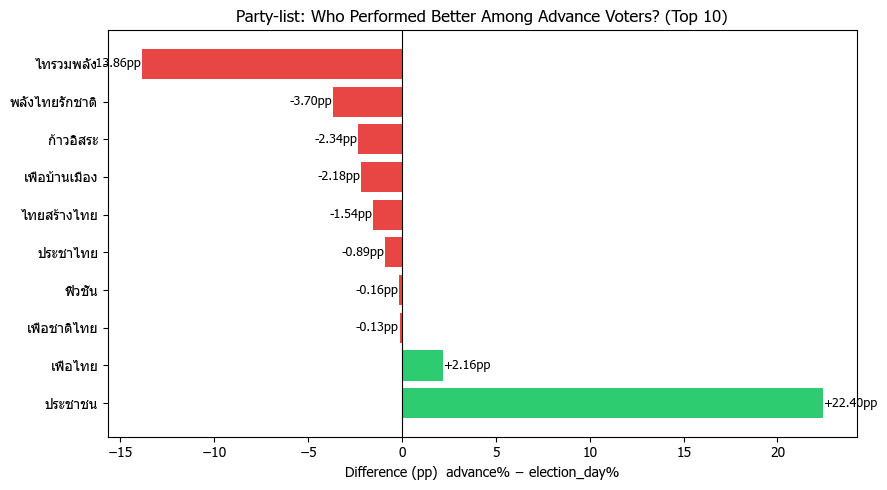

In [9]:
fig, ax = plt.subplots(figsize=(9, 5))

colors = ['#e84545' if v < 0 else '#2ecc71' for v in party_compare['diff_pp']]
bars = ax.barh(party_compare['party_name'], party_compare['diff_pp'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Difference (pp)  advance% − election_day%')
ax.set_title('Party-list: Who Performed Better Among Advance Voters? (Top 10)')

for bar, val in zip(bars, party_compare['diff_pp']):
    offset = 0.05 if val >= 0 else -0.05
    ha     = 'left' if val >= 0 else 'right'
    ax.text(val + offset, bar.get_y() + bar.get_height() / 2,
            f'{val:+.2f}pp', va='center', ha=ha, fontsize=9)

ax.invert_yaxis()
plt.tight_layout()
plt.savefig(FIG / 'party_advance_diff.png', dpi=150)
plt.show()

## 4 · Advance Voting Volume vs Election Day by Amphoe

How large is the advance voting pool relative to election day
in each amphoe? Note: advance_out stations don't have amphoe breakdown
(they're aggregated at constituency level), so we compare totals only.

In [10]:
# Election day total per amphoe
ed_by_amphoe = (
    const_ed
    .groupby('amphoe')['score'].sum()
    .reset_index()
    .rename(columns={'score': 'ed_votes'})
)
# divide by 6 candidates to get unique voters
ed_by_amphoe['ed_votes'] = (ed_by_amphoe['ed_votes'] / 6).round(0).astype(int)

# Advance total (no amphoe breakdown — show as single bar)
adv_total_const = int(const_adv['score'].sum() / 6)

print(f'Advance voters (out-of-district) : {adv_total_const:,}')
print()
print('Election day voters per amphoe:')
print(ed_by_amphoe.sort_values('ed_votes', ascending=False).to_string(index=False))
print(f'\nTotal election day: {ed_by_amphoe["ed_votes"].sum():,}')
print(f'Advance as % of total: {adv_total_const / (adv_total_const + ed_by_amphoe["ed_votes"].sum()) * 100:.1f}%')

Advance voters (out-of-district) : 1,271

Election day voters per amphoe:
          amphoe  ed_votes
     อำเภอน้ำยืน      4748
      อำเภอสำโรง      2491
อำเภอทุ่งศรีอุดม      2113
    อำเภอน้ำขุ่น      1926

Total election day: 11,278
Advance as % of total: 10.1%


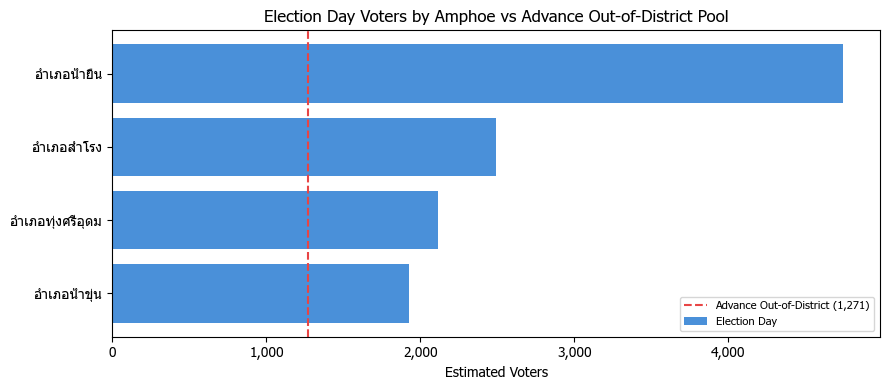

In [11]:
fig, ax = plt.subplots(figsize=(9, 4))

amphoes = ed_by_amphoe.sort_values('ed_votes')['amphoe'].tolist()
votes   = ed_by_amphoe.sort_values('ed_votes')['ed_votes'].tolist()

ax.barh(amphoes, votes, color='#4a90d9', label='Election Day')
ax.axvline(adv_total_const, color='#e84545', linestyle='--',
           label=f'Advance Out-of-District ({adv_total_const:,})')

ax.set_xlabel('Estimated Voters')
ax.set_title('Election Day Voters by Amphoe vs Advance Out-of-District Pool')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(FIG / 'advance_volume.png', dpi=150)
plt.show()

## 5 · Export

In [14]:
const_compare.to_csv(OUT / 'advance_vs_ed_constituency.csv', index=False, encoding='utf-8-sig')
party_compare.to_csv(OUT / 'advance_vs_ed_partylist.csv',    index=False, encoding='utf-8-sig')

print('Exported OK')

Exported OK


## Summary

| File | Description |
|------|-------------|
| `advance_vs_ed_constituency.csv` | Advance vs election day share per candidate |
| `advance_vs_ed_partylist.csv` | Advance vs election day share per party (top 10) |

**Next:** `05_external_data.ipynb` — enrich with 2023 results + demographic data